### Assignment 4

Title: To study and understand the concept to recognize the numbers 0, 1, 2, …9. A 5 * 3 matrix forms. 

Problem Statement: Write a python program to recognize the numbers 0, 1, 2, ..9. A 5 * 3 matrix forms the numbers. For any valid point it is taken as 1 and invalid 
point it is taken as 0. The net has to be trained to recognise all the numbers and when the test data is given, the network has to recognise the particular numbers 

In [14]:
# !pip install numpy matplotlib

# (Latest version upgrade)
# !pip install -U numpy matplotlib

In [15]:
import numpy as np
import matplotlib.pyplot as plt

In [16]:
# 1. Data Setup (5x3 digit patterns)
X = np.array([
    [1,1,1, 1,0,1, 1,0,1, 1,0,1, 1,1,1],  # 0
    [0,1,0, 1,1,0, 0,1,0, 0,1,0, 1,1,1],  # 1
    [1,1,1, 0,0,1, 1,1,1, 1,0,0, 1,1,1],  # 2
    [1,1,1, 0,0,1, 1,1,1, 0,0,1, 1,1,1],  # 3
    [1,0,1, 1,0,1, 1,1,1, 0,0,1, 0,0,1],  # 4
    [1,1,1, 1,0,0, 1,1,1, 0,0,1, 1,1,1],  # 5
    [1,1,1, 1,0,0, 1,1,1, 1,0,1, 1,1,1],  # 6
    [1,1,1, 0,0,1, 0,0,1, 0,0,1, 0,0,1],  # 7
    [1,1,1, 1,0,1, 1,1,1, 1,0,1, 1,1,1],  # 8
    [1,1,1, 1,0,1, 1,1,1, 0,0,1, 1,1,1]   # 9
])

In [17]:
# Function to visualize patterns
def display_patterns(data, titles, rows=2, cols=5):
    plt.figure(figsize=(12, 6))
    for i in range(len(data)):
        plt.subplot(rows, cols, i + 1)
        # Reshape the 15 features into a 5x3 grid
        grid = data[i].reshape(5, 3)
        plt.imshow(grid, cmap='binary')
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

Visualizing Training Set:


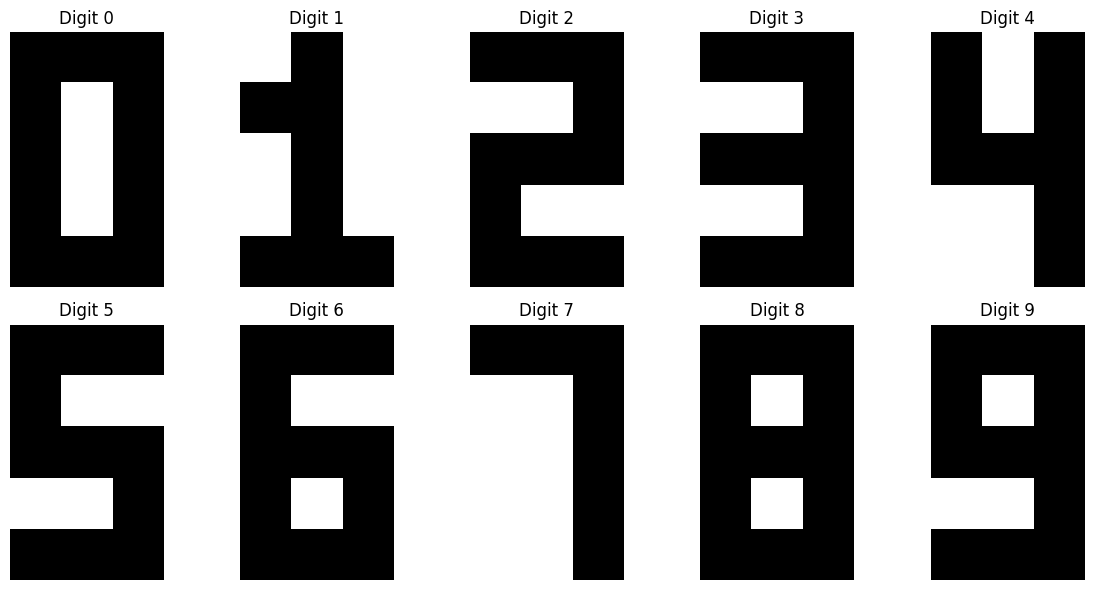

In [18]:
# Visualize training data
print("Visualizing Training Set:")
display_patterns(X, [f"Digit {i}" for i in range(10)])

In [19]:
# 2. Perceptron training function (One-vs-All)
def train_perceptron(X, y_binary, lr=0.1, epochs=100):
    w = np.zeros(X.shape[1])
    b = 0
    for _ in range(epochs): 

        for i in range(len(X)):

            z = np.dot(X[i], w) + b
            y_pred = 1 if z >= 0 else -1

            if y_pred != y_binary[i]:
                
                w += lr * y_binary[i] * X[i]
                b += lr * y_binary[i]

    return w, b

In [ ]:
# Train models
models = []
for digit in range(10):

    y_binary = np.where(np.arange(10) == digit, 1, -1)
    # print(y_binary)
    w, b = train_perceptron(X, y_binary)
    models.append((w, b))

[(array([-0.1,  0. , -0.1,  0.2, -0.1, -0.1,  0. , -0.6, -0.1,  0.2, -0.1,
          0.2,  0.1,  0.1, -0.2]),
  np.float64(-0.2)),
 (array([-0.1,  0. , -0.1,  0. ,  0.1, -0.1, -0.1,  0.1, -0.1, -0.1,  0.1,
         -0.1,  0. ,  0. ,  0. ]),
  np.float64(0.0)),
 (array([ 0. , -0.1,  0. , -0.2, -0.1,  0. ,  0. ,  0. ,  0. ,  0.5, -0.1,
         -0.6, -0.1, -0.1, -0.1]),
  np.float64(-0.1)),
 (array([-0.1,  0.1, -0.1, -0.5,  0. ,  0.1,  0. ,  0.1, -0.1, -0.3,  0. ,
          0.1,  0.2,  0.2, -0.1]),
  np.float64(-0.1)),
 (array([ 0. , -0.1,  0. ,  0. ,  0. ,  0. ,  0. ,  0.1,  0. , -0.1,  0. ,
          0. , -0.1, -0.1,  0. ]),
  np.float64(0.0)),
 (array([ 0.1, -0.1,  0.1,  0.1, -0.2, -1. ,  0.3,  0.2,  0.1, -1.2, -0.2,
          0.1,  0.1,  0.1, -0.1]),
  np.float64(-0.1)),
 (array([ 0. , -0.1,  0. ,  0. , -0.1, -0.3,  0.1,  0.1,  0. ,  0.1, -0.1,
          0. ,  0. ,  0. , -0.1]),
  np.float64(-0.1)),
 (array([ 0. ,  0. ,  0. , -0.1,  0. ,  0. , -0.1,  0. ,  0. , -0.1,  0. ,
          

In [21]:
# 3. Prediction function
def predict(x, models):
    scores = [np.dot(x, w) + b for w, b in models]
    return np.argmax(scores)

In [22]:
# Test on training patterns
print("\nTesting all digit patterns:")
for i in range(10):
    pred = predict(X[i], models)
    status = "✓" if pred == i else "✗"
    print(f"Input: {i} | Predicted: {pred} | {status}")


Testing all digit patterns:
Input: 0 | Predicted: 0 | ✓
Input: 1 | Predicted: 1 | ✓
Input: 2 | Predicted: 2 | ✓
Input: 3 | Predicted: 3 | ✓
Input: 4 | Predicted: 4 | ✓
Input: 5 | Predicted: 5 | ✓
Input: 6 | Predicted: 6 | ✓
Input: 7 | Predicted: 7 | ✓
Input: 8 | Predicted: 8 | ✓
Input: 9 | Predicted: 9 | ✓


In [23]:
# 4. Noisy Input Test & Visualization
noisy_0 = np.array([1,1,1, 1,0,1, 1,0,0, 1,0,1, 1,1,1])  
print(f"\nNoisy input predicted as: {predict(noisy_0, models)}")


Noisy input predicted as: 0


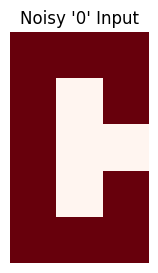

In [24]:
plt.figure(figsize=(3, 3))
plt.imshow(noisy_0.reshape(5, 3), cmap='Reds') # Using Red to highlight noise
plt.title("Noisy '0' Input")
plt.axis('off')
plt.show()